# Axial Expansion Demo
In ARMI, there are two types of axial expansion:
  1. thermal expansion
  2. prescribed expansion
     - Useful for all non-thermal based expansion. E.g., irradiation-based expansion.

Note, the current implementation _only_ supports pin-type assemblies and does not expand control assemblies (the latter is coming soon!).

We begin by getting a test reactor to play with.

In [1]:
import armi
armi.configure()

from armi.tests import TEST_ROOT
from armi.reactor.tests.test_reactors import loadTestReactor

_o, r = loadTestReactor(TEST_ROOT)


       +===================================================+
       |            _      ____     __  __    ___          |
       |           / \    |  _ \   |  \/  |  |_ _|         |
       |          / _ \   | |_) |  | |\/| |   | |          |
       |         / ___ \  |  _ <   | |  | |   | |          |
       |        /_/   \_\ |_| \_\  |_|  |_|  |___|         |
       |        Advanced  Reactor  Modeling Interface      |
       |                                                   |
       |                    version 0.2.3                  |
       |                                                   |
       +===================================================+
[warn] Ignoring invalid settings: transientForSensitivity
       	maxRegionDensityIterations
       	clusterExclusive
       	maxFlowZones
       	eqRingSchedule
       	epsBurnTime
       	percentNaReduction
       	refType
       	max2SigmaCladIDT
       	nodeGroup
       	economics
       	BOL
=========== Case Information =

Before we start expanding, let's get a reference visualization to compare against later. The plot below shows the "blueprints assemblies" (i.e., those defined in the blueprints, as is).

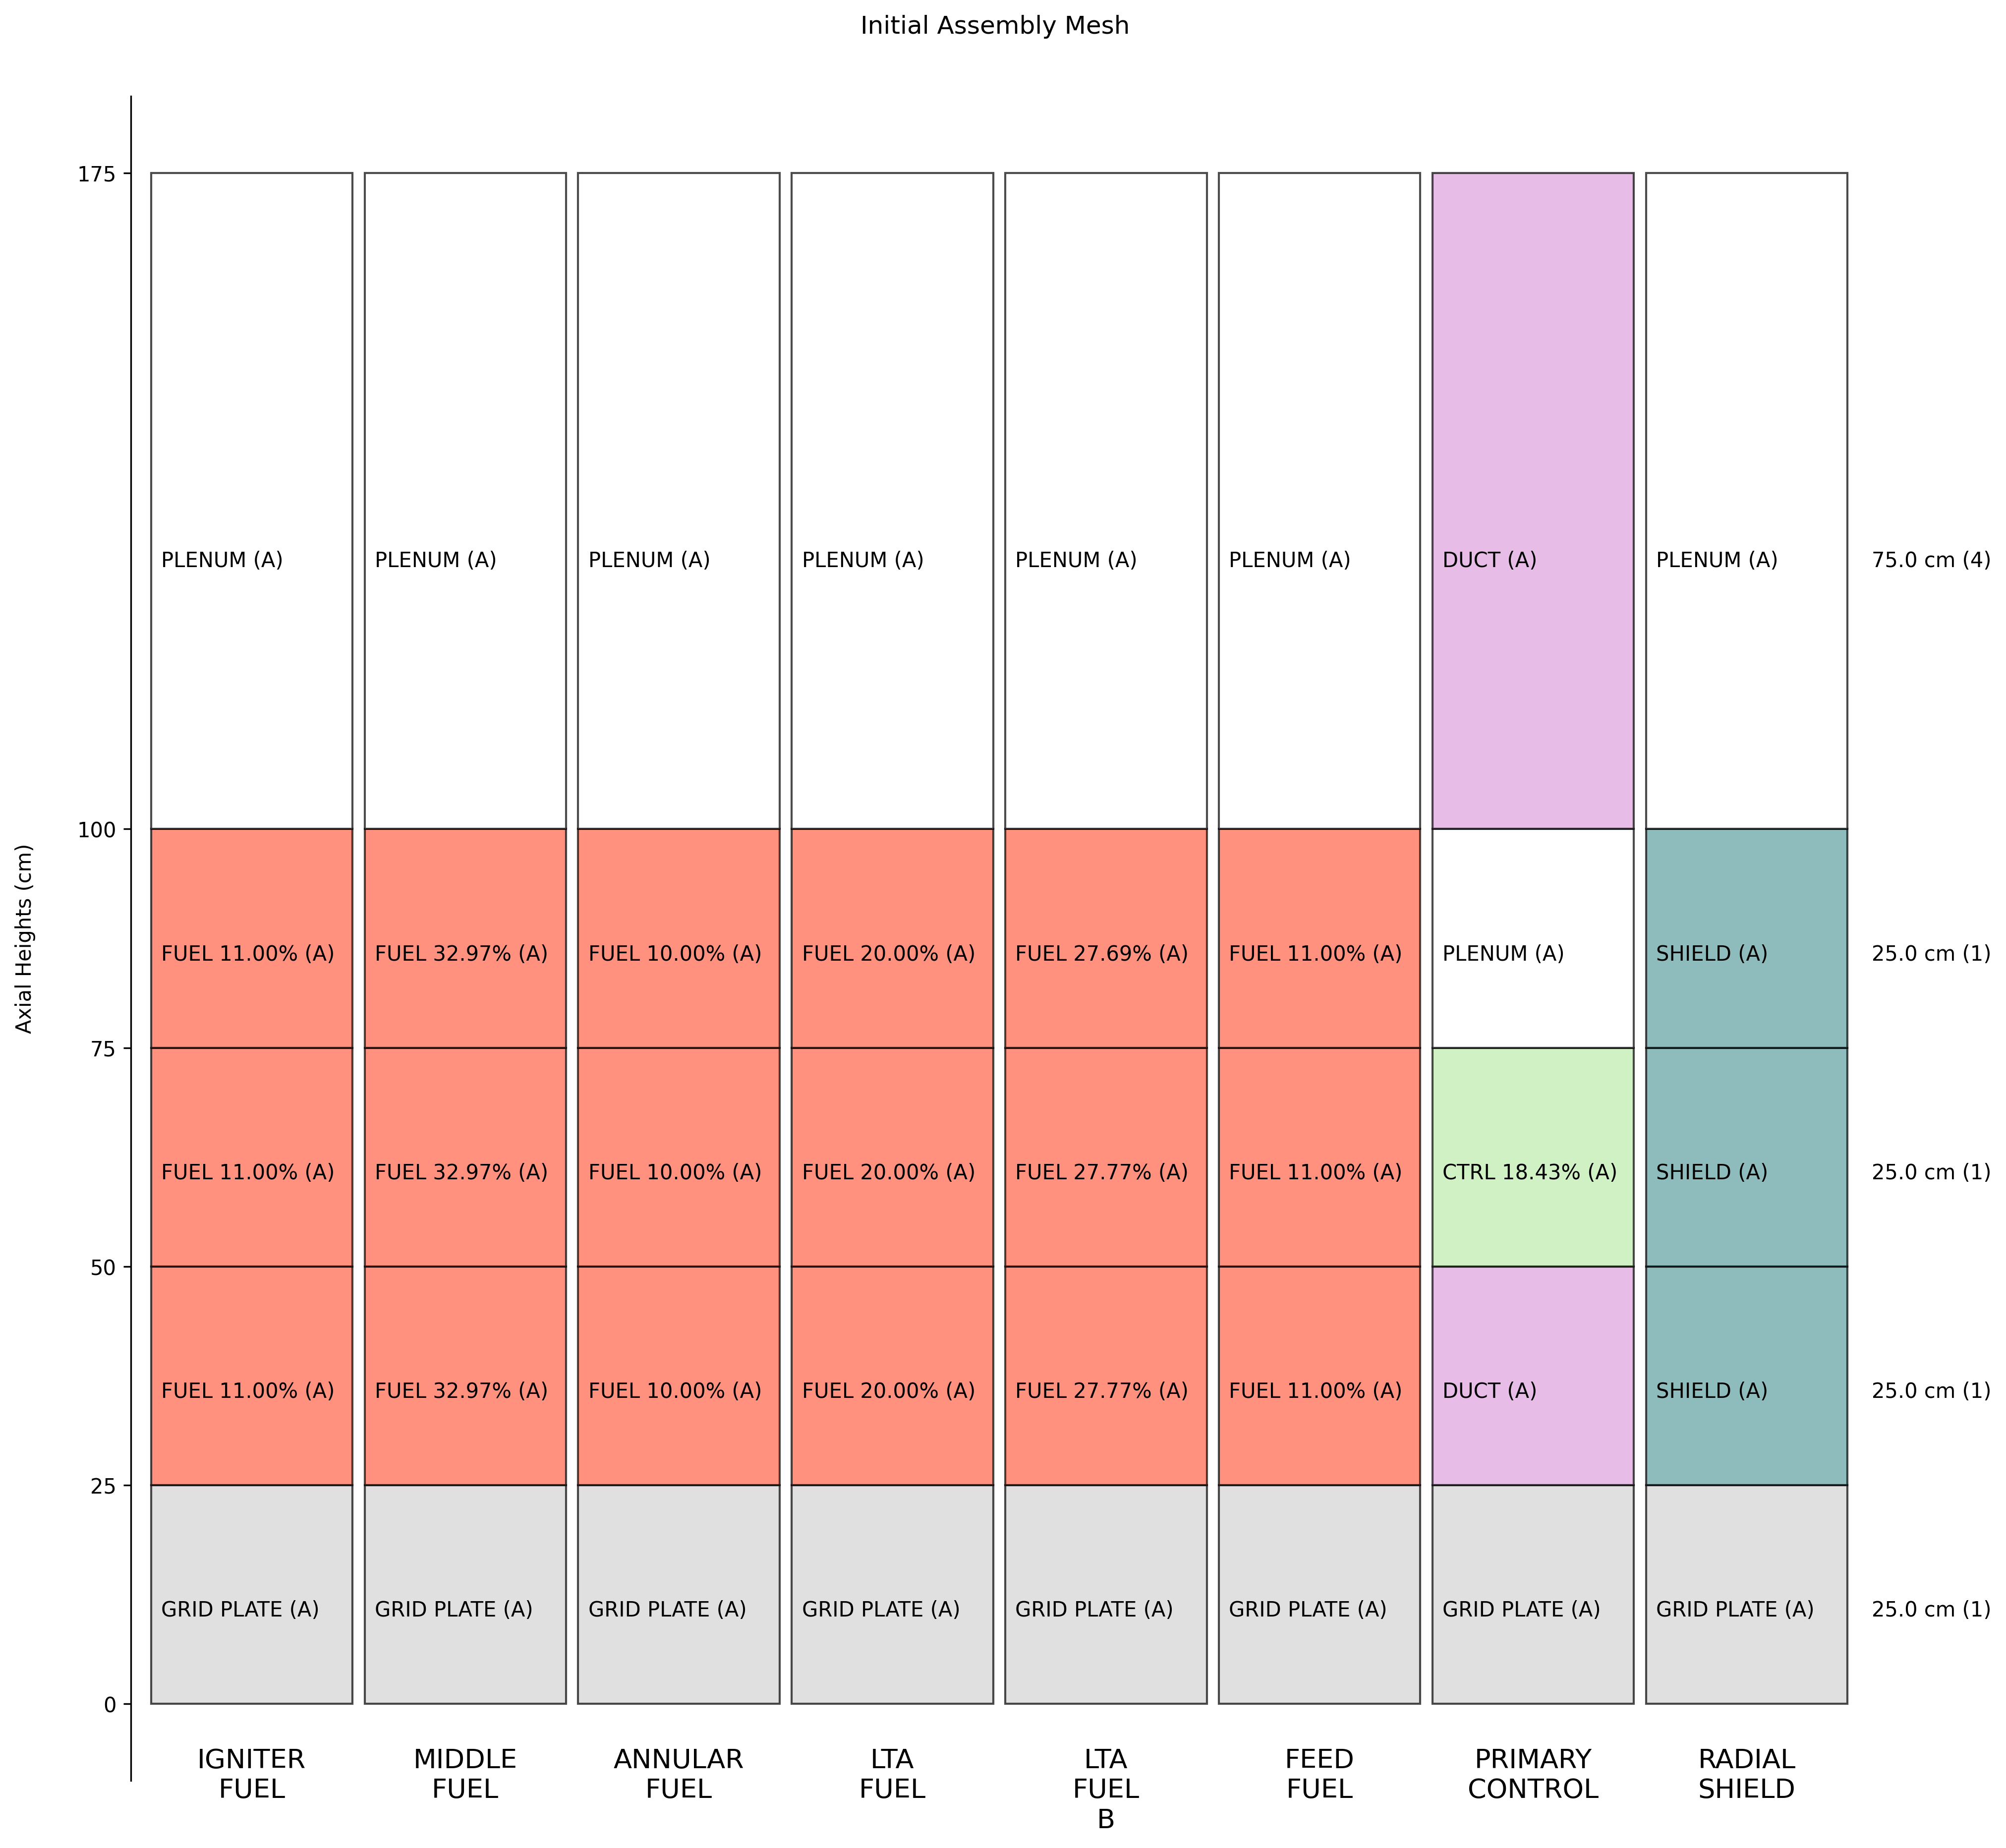

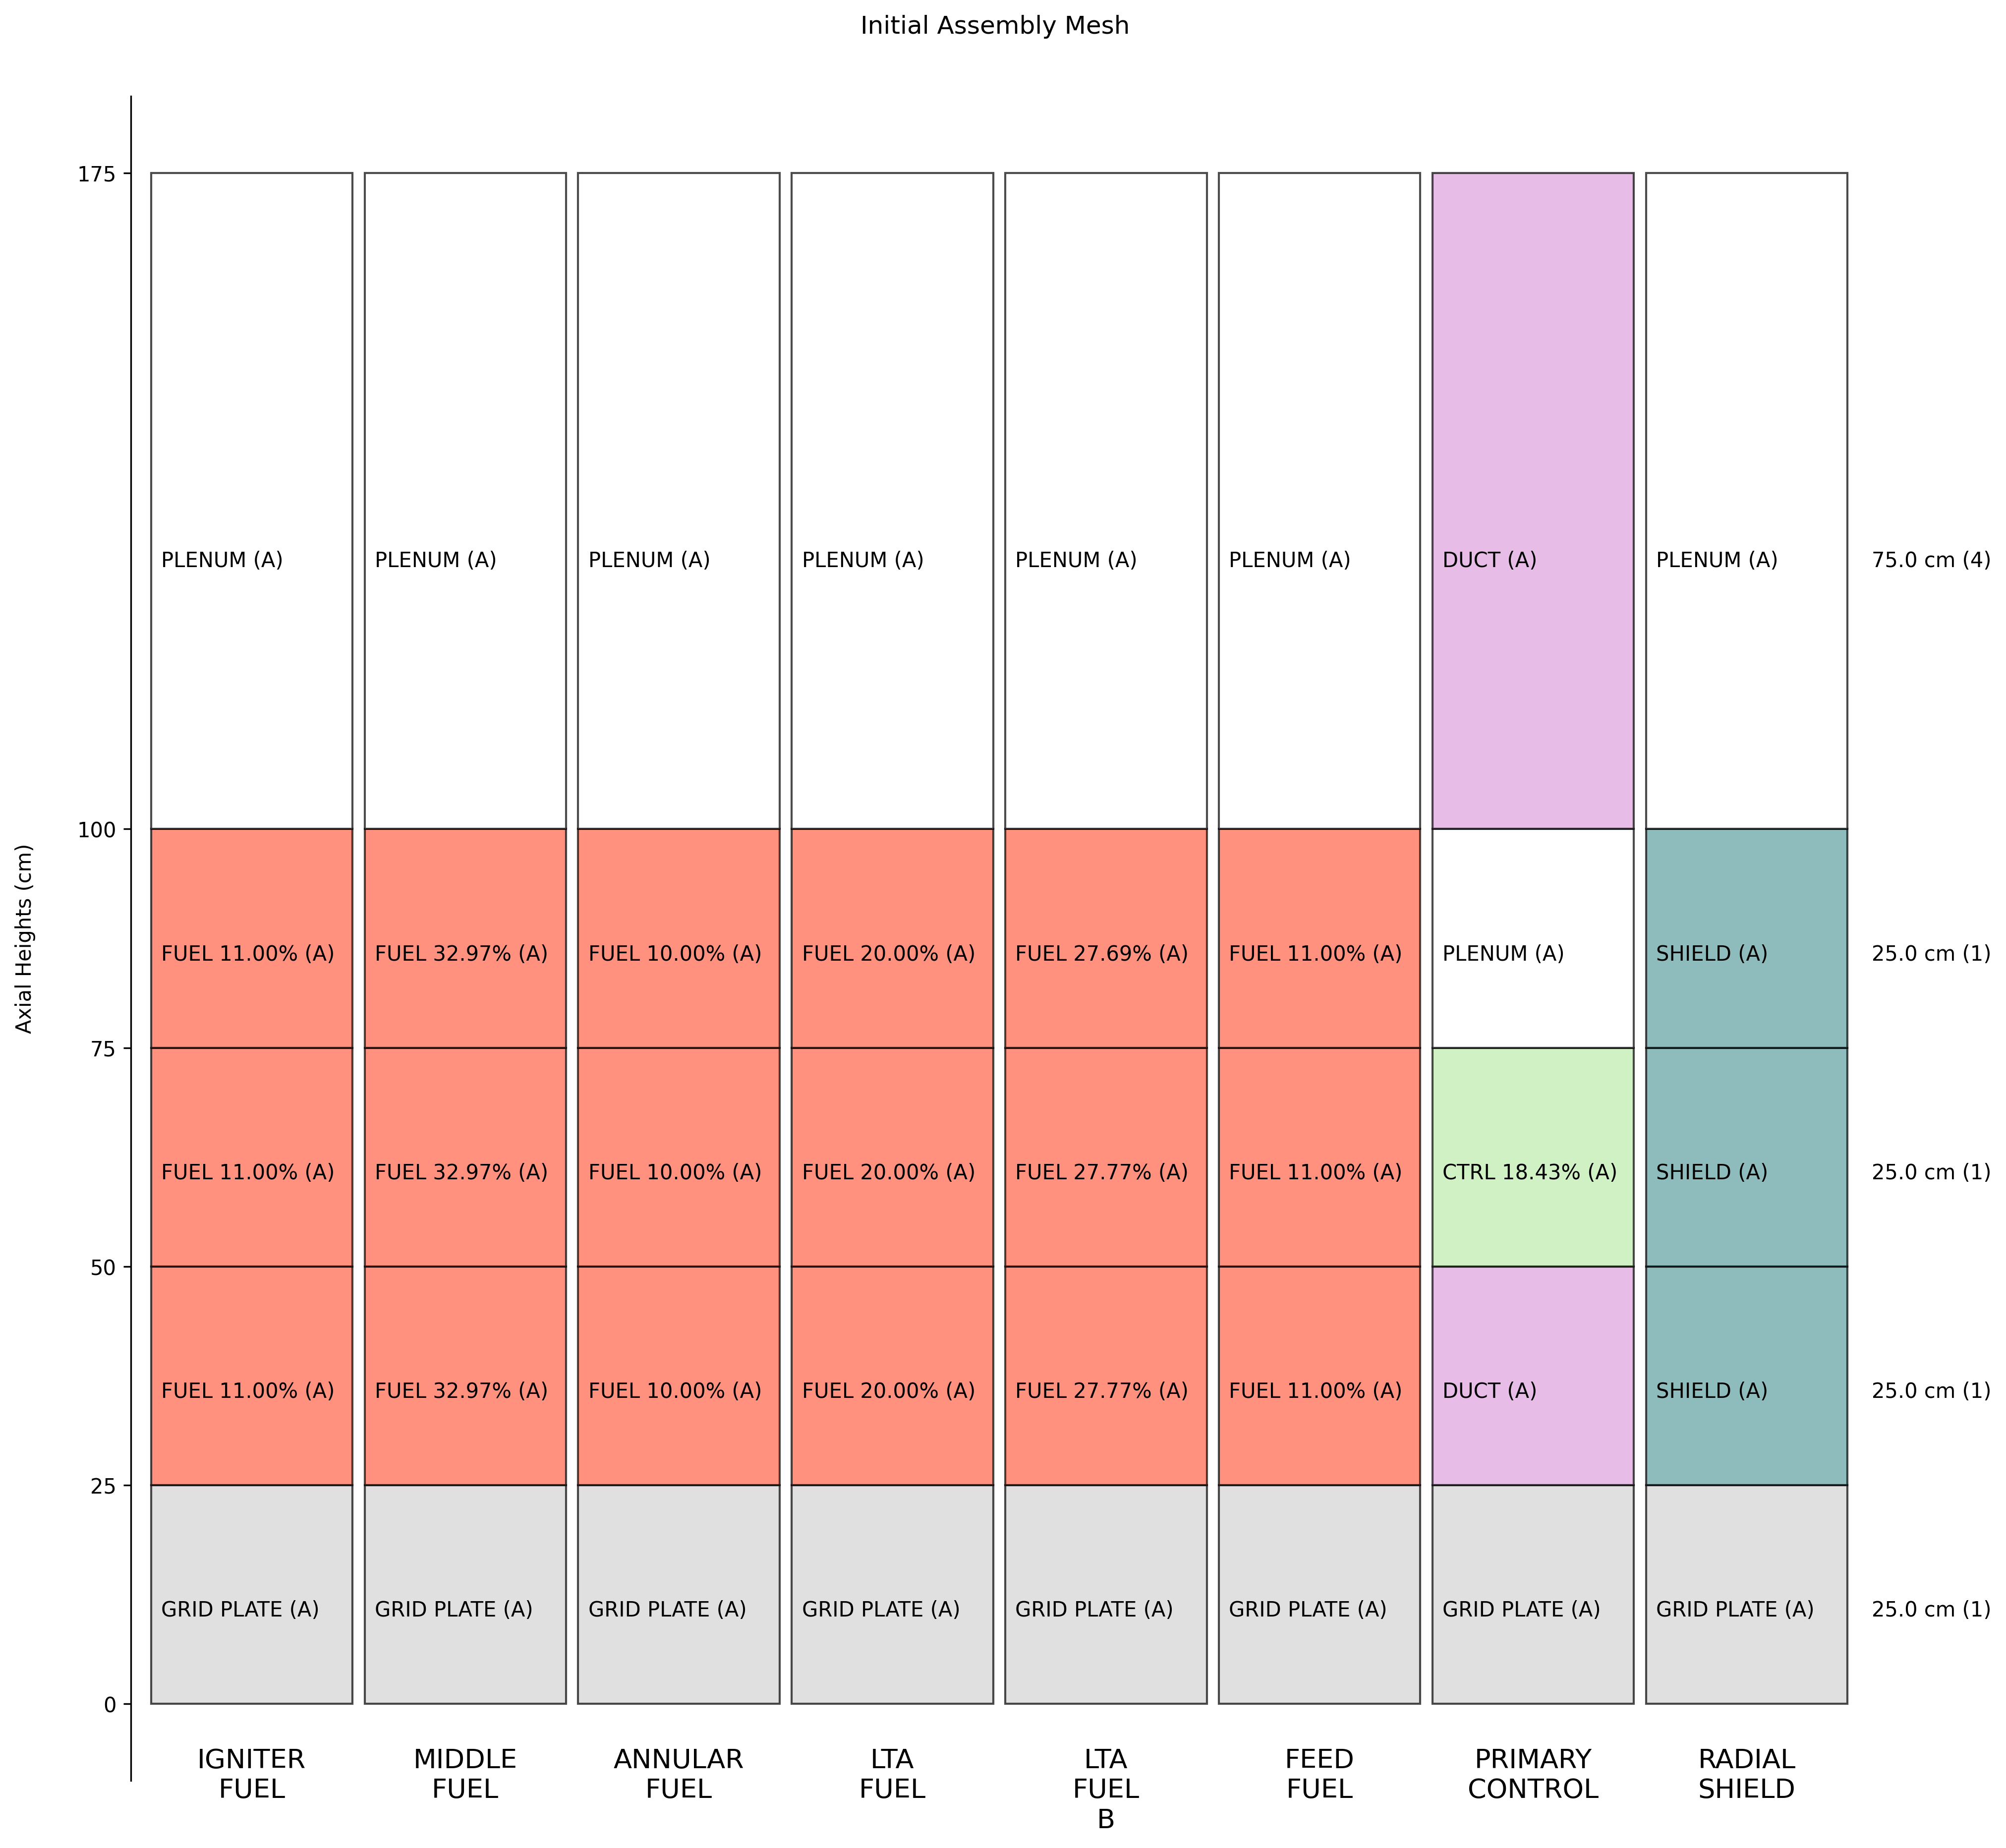

In [2]:
from armi.utils import plotting

plotting.plotAssemblyTypes(
    blueprints=r.blueprints,
    showBlockAxMesh=True,
    title="Initial Assembly Mesh",
    yAxisLabel="Axial Heights (cm)",
)

With the reference visualized, we can now start axially expanding assemblies. The axial expansion functionality lives within armi.reactor.converters.axialExpansionChanger.

The general workflow to use axial expansion in ARMI is as follows:
1. Initialize an instance of the axial expansion class.
2. Assign/set an assembly to the changer.
3. Assign expansion factors (compute first, if necessary).
4. Execute expansion.

### Prescribed expansion
In the following, we will expand each fuel component within the "igniter fuel", "annular fuel", and "feed fuel" assemblies by 10%. This example illustrates burnup-based axial expansion/growth of nuclear fuel.

In [4]:
from armi.reactor.flags import Flags

## extract blueprints assemblies
blueprintAssemblies = list(r.blueprints.assemblies.values() )

## extract assemblies to expand
assemTypesToExpand = ["igniter fuel", "annular fuel", "feed fuel"]
assemsToExpand = []
for a in blueprintAssemblies:
    if a.getType() in assemTypesToExpand:
        assemsToExpand.append(a)

## extract fuel components
componentsToExpand = [
    c 
    for a in assemsToExpand
    for b in a.getChildrenWithFlags(Flags.FUEL) 
    for c in b if c.hasFlags(Flags.FUEL)
]

## assign 10% expansion for each component
expPercents = [0.1 for i in componentsToExpand]

Now we have the data we need to actually execute the expansion.

In [5]:
from armi.reactor.converters.axialExpansionChanger import AxialExpansionChanger

# Step 1
axialExpChngr = AxialExpansionChanger()

for a in assemsToExpand:
    # Step 2
    axialExpChngr.setAssembly(a)

    # Step 3
    axialExpChngr.expansionData.setExpansionFactors(componentsToExpand, expPercents)

    # Step 4
    axialExpChngr.axiallyExpandAssembly()

Let's check out what happened.

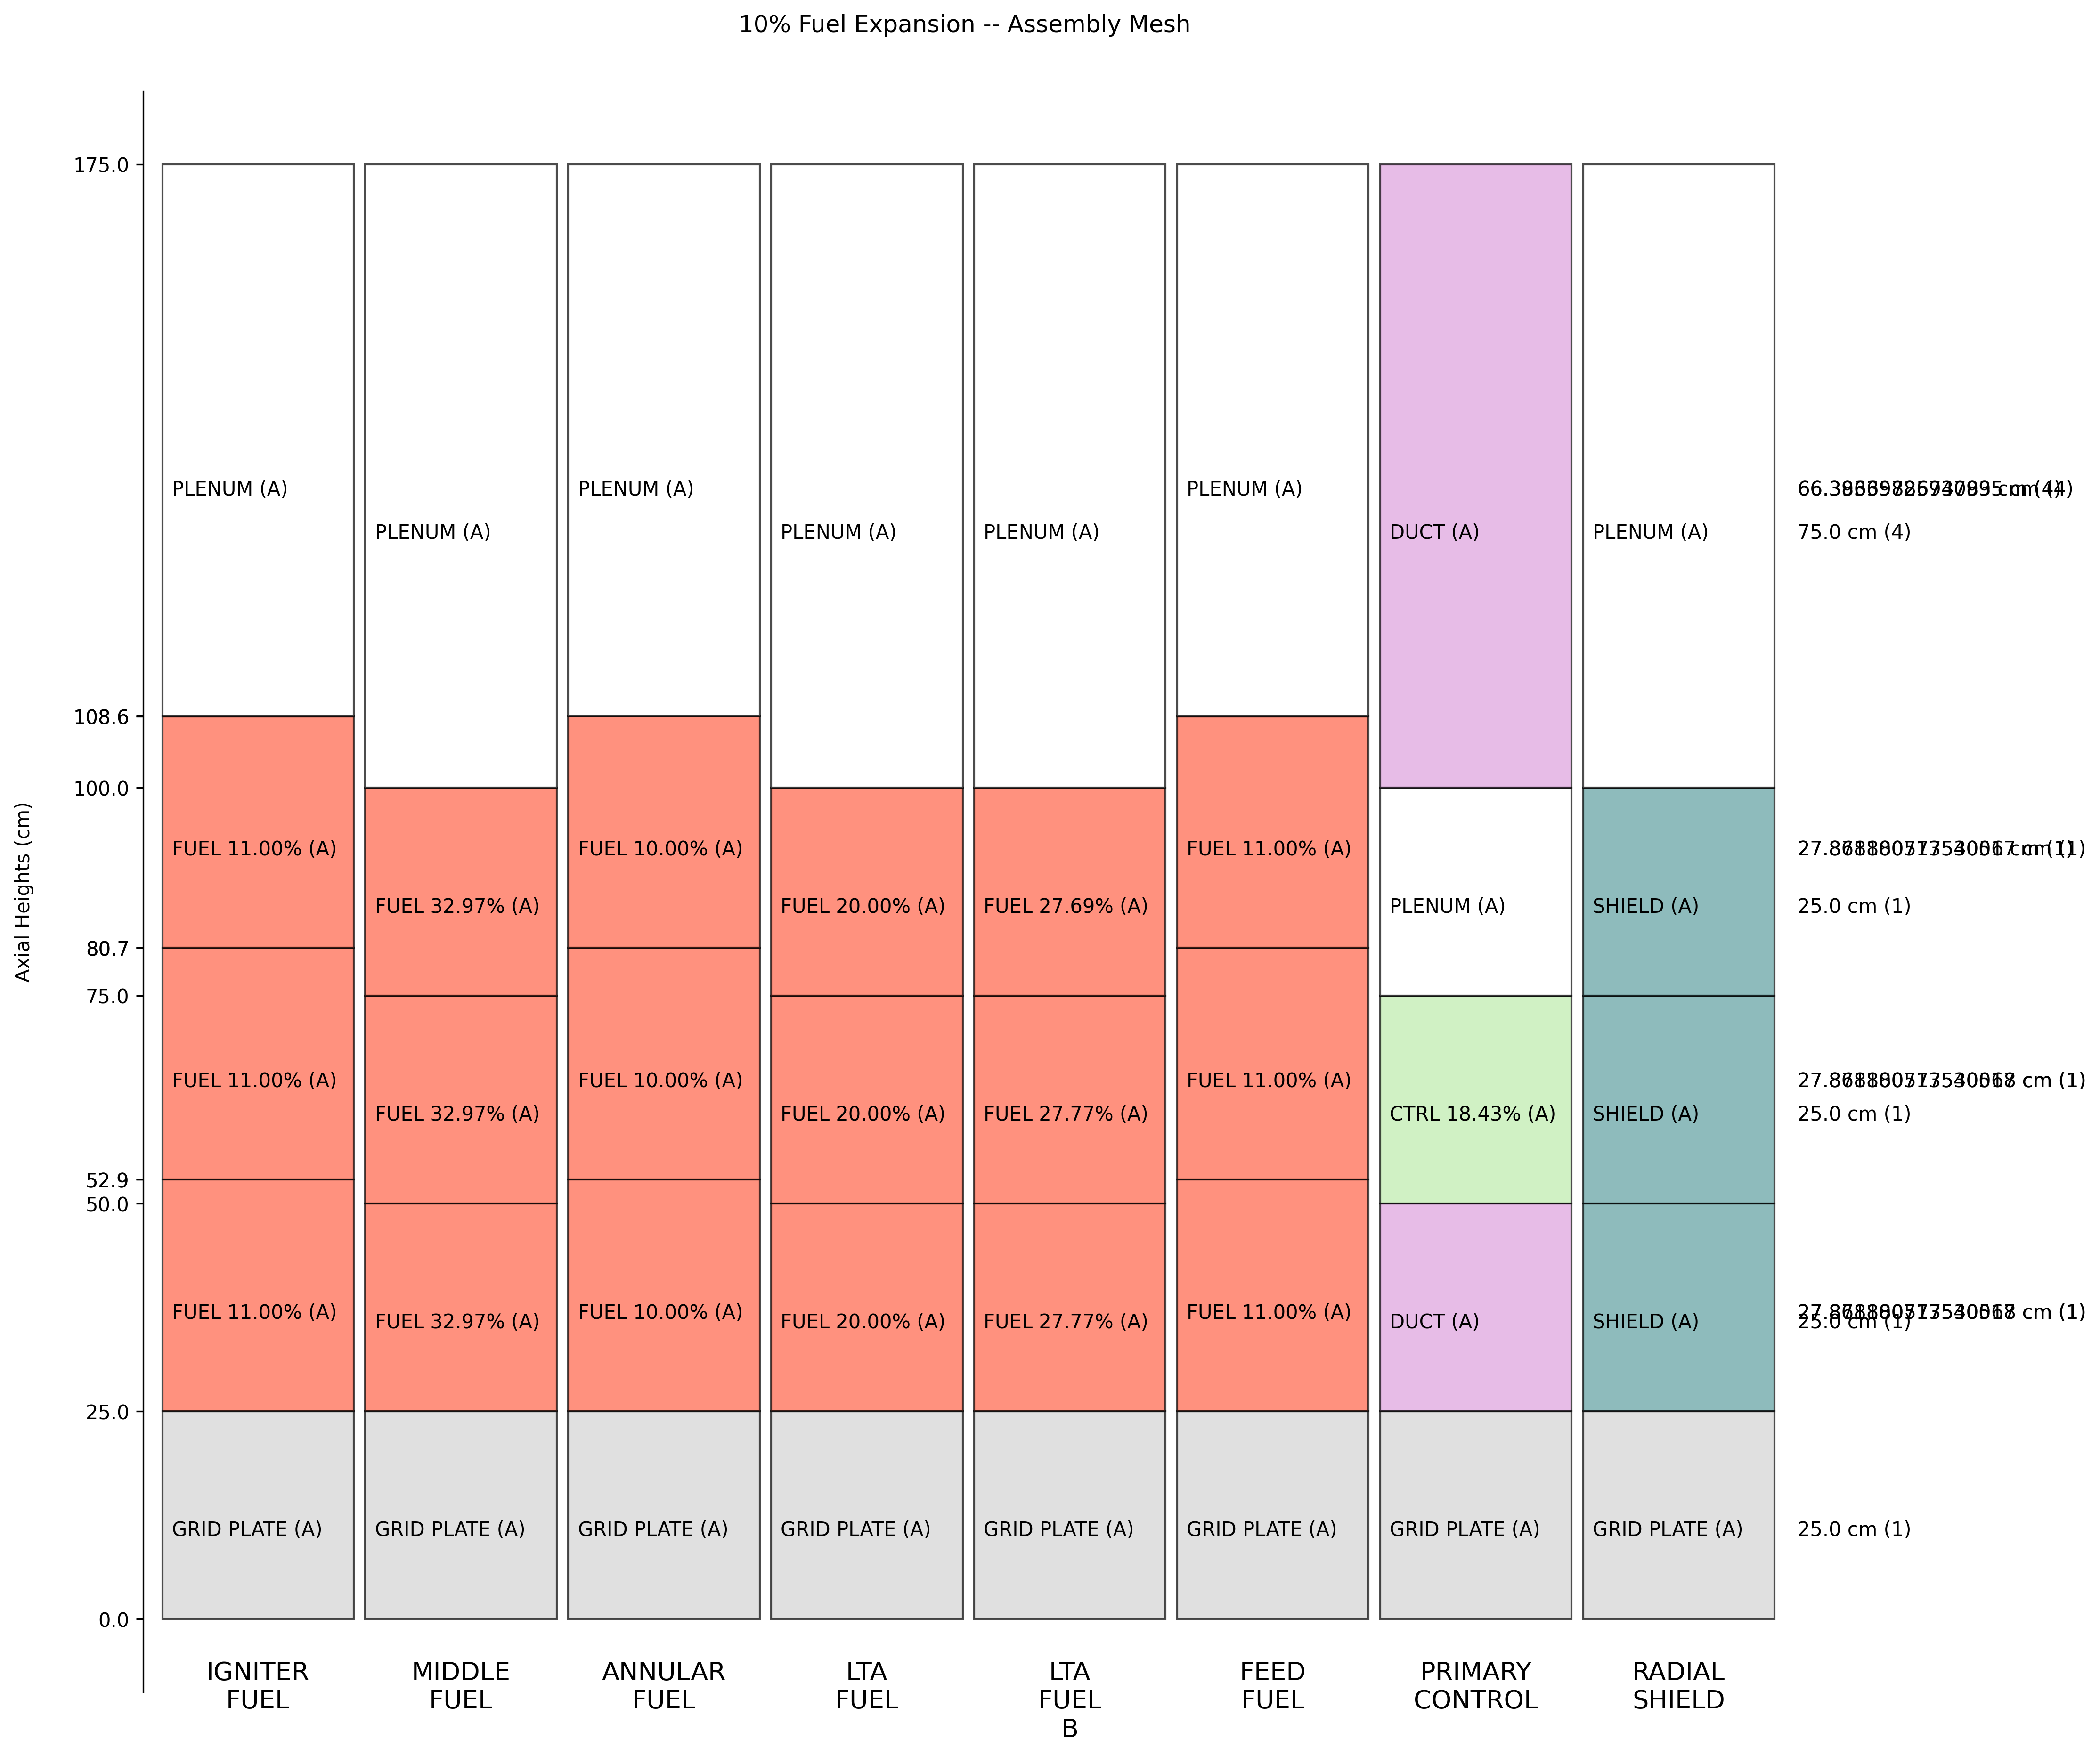

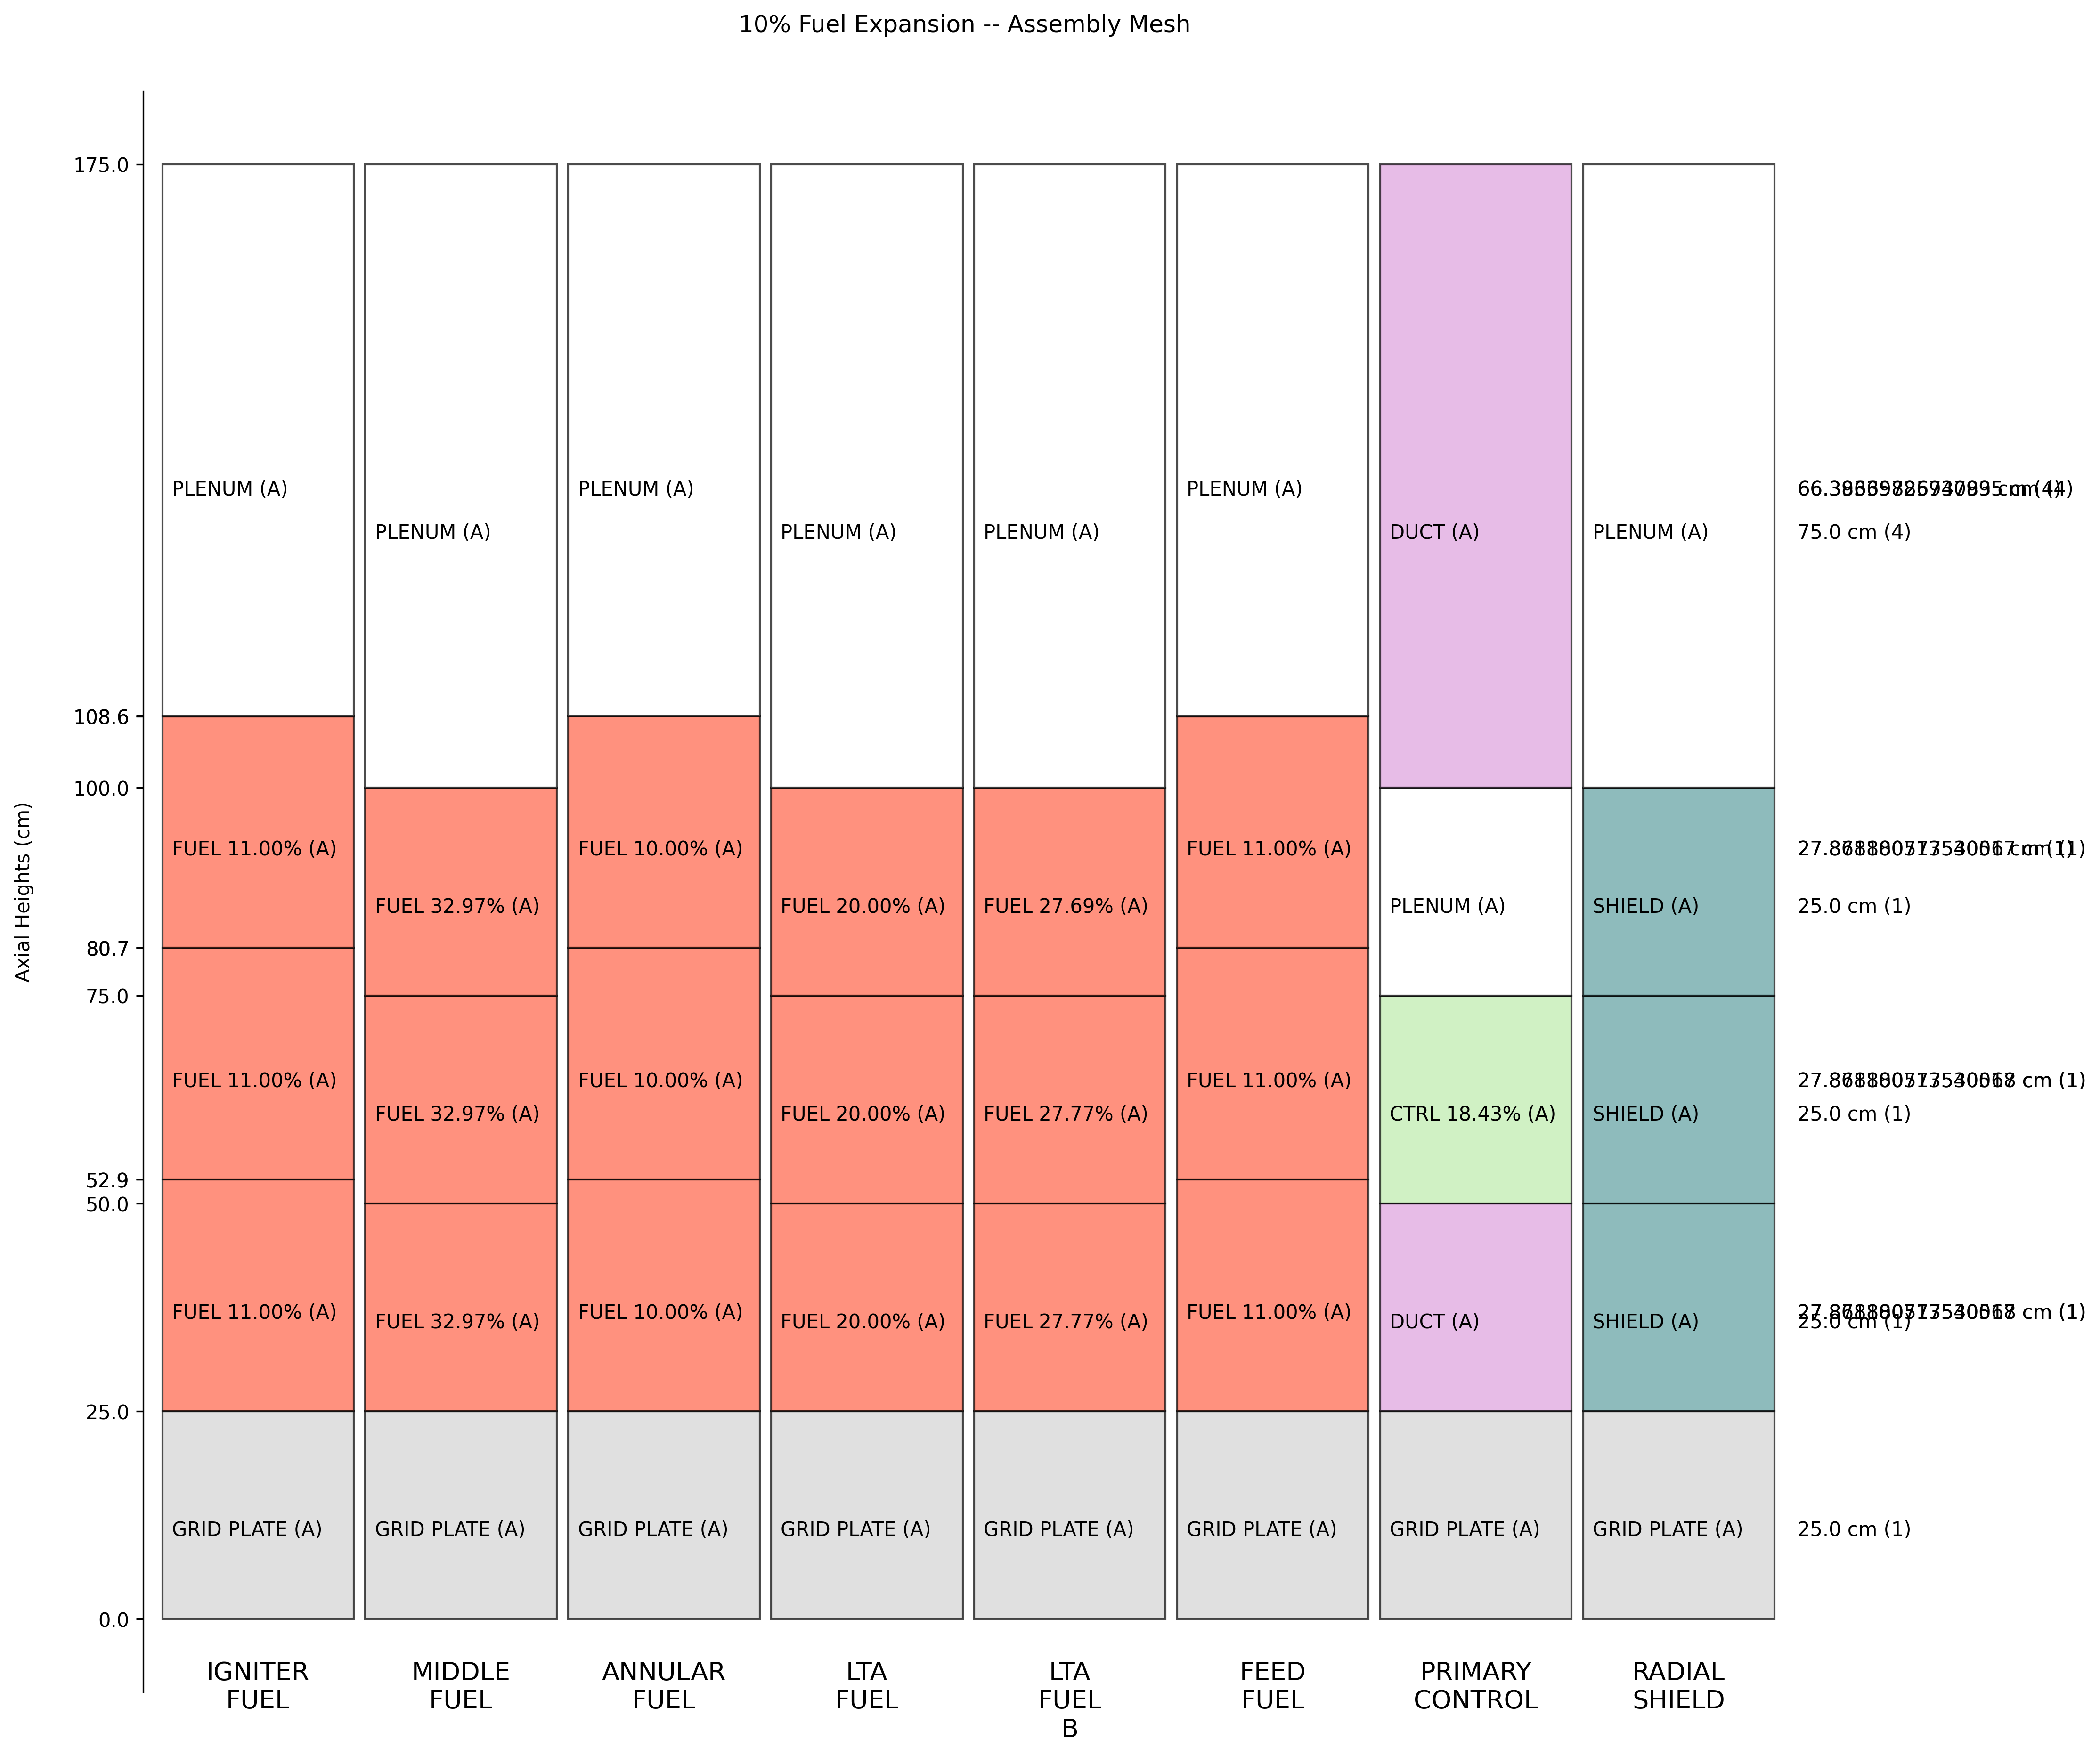

In [9]:
plotting.plotAssemblyTypes(
    blueprints=r.blueprints,
    showBlockAxMesh=True,
    title="10% Fuel Expansion -- Assembly Mesh",
    yAxisLabel="Axial Heights (cm)",
)

Comparing to the reference figure we observe a few changes:
1. Each of the fuel blocks in `assemsToExpand` grew 10% (height of 25.0 cm --> 27.5 cm)
2. Each plenum within `assemsToExpand` shrunk by 7.5 cm (10%) - fuel blocks expanding into plenum, thereby reducing plenum volume.

## Thermal Expansion
Executing thermal expansion in ARMI is very similar to the above process. The only differences are in how we obtain the thermal expansion coefficients.

Rather than manually prescribing expansion coefficients, we can use the temperature difference between the `inputTemperatureInC` and `temperatureInC` on the component to compute thermal expansion coefficients. The method `computeThermalExpansionFactors` also does the expansion coefficient assignment.

In [7]:
# Step 1
axialExpChngr = AxialExpansionChanger()

for a in assemsToExpand:
    # Step 2
    axialExpChngr.setAssembly(a)

    # Step 3
    axialExpChngr.expansionData.computeThermalExpansionFactors()

    # Step 4
    axialExpChngr.axiallyExpandAssembly()

Let's check out what happened.

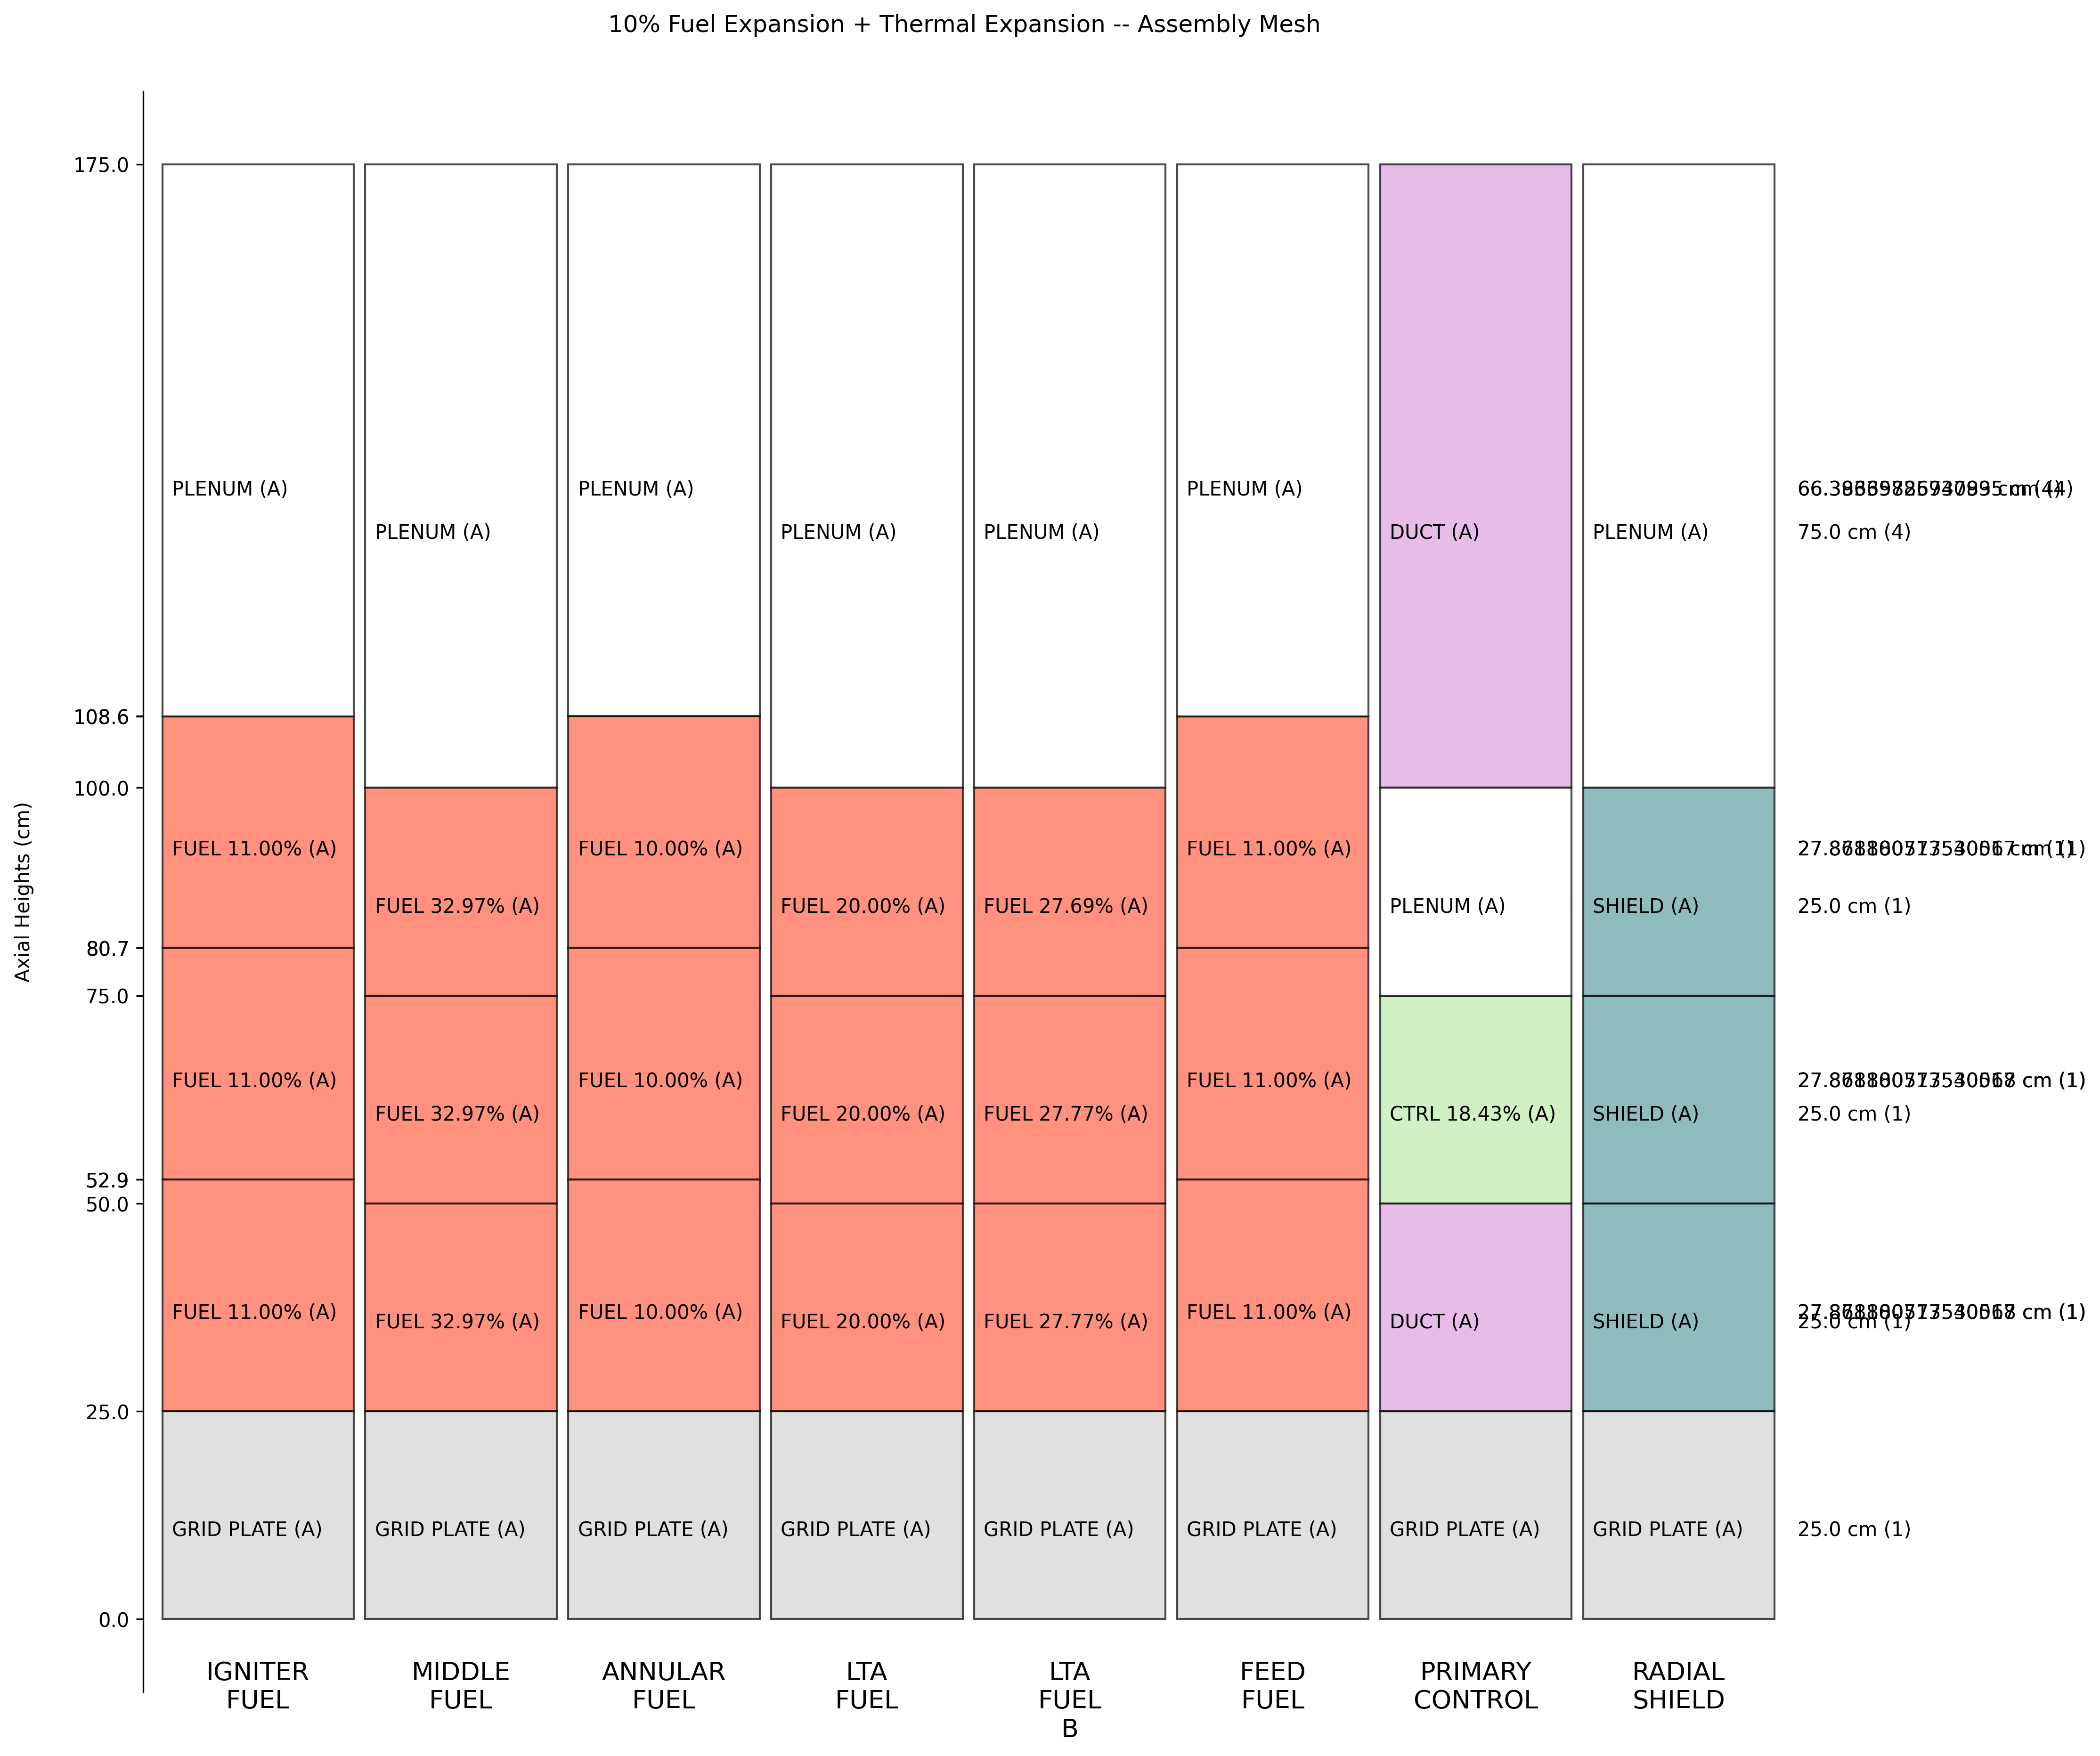

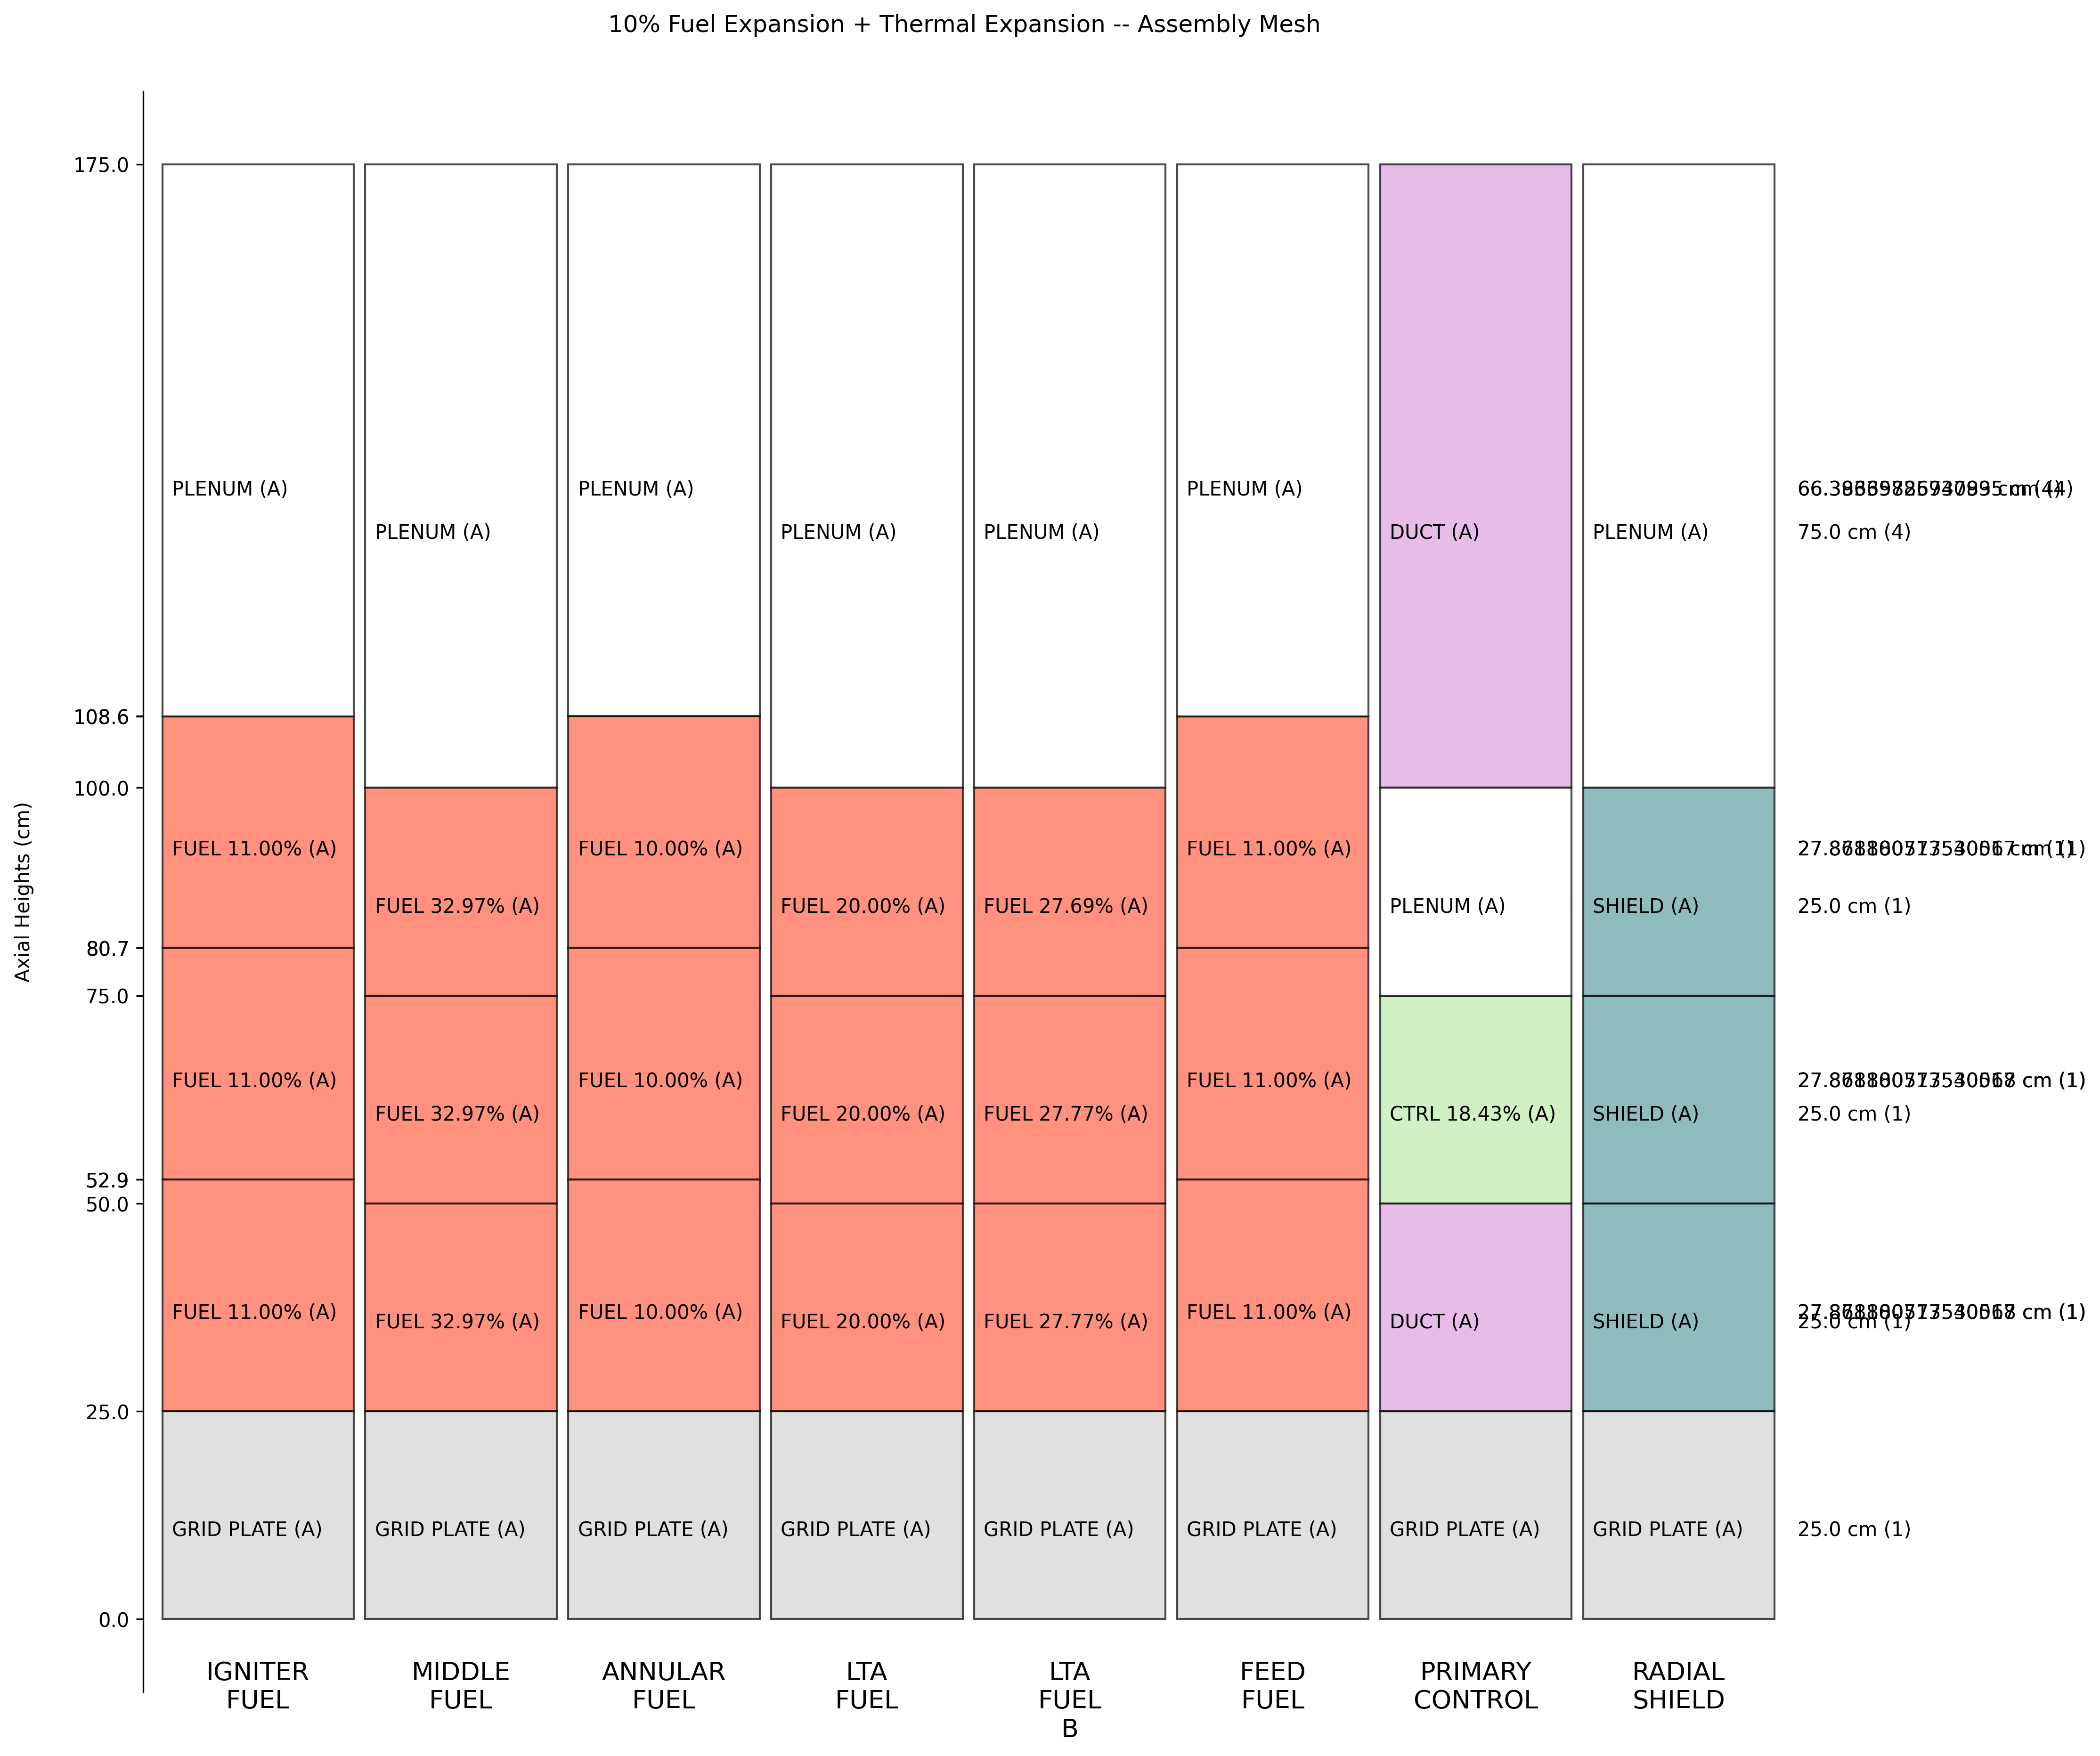

In [10]:
plotting.plotAssemblyTypes(
    blueprints=r.blueprints,
    showBlockAxMesh=True,
    title="10% Fuel Expansion + Thermal Expansion -- Assembly Mesh",
    yAxisLabel="Axial Heights (cm)",
)

We observe that some blocks do not expand (e.g., `GRID PLATE`); this is due to a $\Delta T = 0.0$ C. Differing degrees of expansion across different blocks are dependent on the differences between $\Delta T$ and the coefficients of thermal expansion for the materials within the blocks.